In [3]:
!pip install pyarrow


In [4]:
import pandas as pd

In [5]:
import pickle

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import mean_squared_error

In [8]:
mean_squared_error

<function sklearn.metrics._regression.mean_squared_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average', squared=True)>

In [9]:
import os, mlflow, pathlib

mlflow.set_experiment("nyc-taxi-experiment")



<Experiment: artifact_location='file:///workspaces/mlops-zoomcamp/03%20-%20training/experiment_tracking/mlruns/692223740993741424', creation_time=1771341056789, experiment_id='692223740993741424', last_update_time=1771341056789, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}>

In [10]:
pd.__version__

'1.4.2'

In [11]:
def read_dataframe(filename):

    df = pd.read_parquet(filename)

    df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    numerical = ['trip_distance']

    df[categorical] = df[categorical].astype(str)

    return df

In [12]:
df_train = read_dataframe('./data/green_tripdata_2021-01.parquet')
df_val = read_dataframe('./data/green_tripdata_2021-02.parquet')


In [13]:
len(df_train), len(df_val)

(73908, 61921)

In [14]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [15]:
df_val

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration,PU_DO
0,2,2021-02-01 00:34:03,2021-02-01 00:51:58,N,1.0,130,205,5.0,3.66,14.00,...,10.00,0.0,None,0.3,25.30,1.0,1.0,0.00,17.916667,130_205
1,2,2021-02-01 00:04:00,2021-02-01 00:10:30,N,1.0,152,244,1.0,1.10,6.50,...,0.00,0.0,None,0.3,7.80,2.0,1.0,0.00,6.500000,152_244
2,2,2021-02-01 00:18:51,2021-02-01 00:34:06,N,1.0,152,48,1.0,4.93,16.50,...,0.00,0.0,None,0.3,20.55,2.0,1.0,2.75,15.250000,152_48
3,2,2021-02-01 00:53:27,2021-02-01 01:11:41,N,1.0,152,241,1.0,6.70,21.00,...,0.00,0.0,None,0.3,22.30,2.0,1.0,0.00,18.233333,152_241
4,2,2021-02-01 00:57:46,2021-02-01 01:06:44,N,1.0,75,42,1.0,1.89,8.50,...,2.45,0.0,None,0.3,12.25,1.0,1.0,0.00,8.966667,75_42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64567,2,2021-02-28 22:19:00,2021-02-28 22:29:00,None,NaN,129,7,NaN,2.63,10.04,...,0.00,0.0,None,0.3,10.34,NaN,NaN,NaN,10.000000,129_7
64568,2,2021-02-28 23:18:00,2021-02-28 23:27:00,None,NaN,116,166,NaN,1.87,8.33,...,1.89,0.0,None,0.3,10.52,NaN,NaN,NaN,9.000000,116_166
64569,2,2021-02-28 23:44:00,2021-02-28 23:58:00,None,NaN,74,151,NaN,2.40,12.61,...,0.00,0.0,None,0.3,12.91,NaN,NaN,NaN,14.000000,74_151
64570,2,2021-02-28 23:07:00,2021-02-28 23:14:00,None,NaN,42,42,NaN,1.11,11.95,...,0.00,0.0,None,0.3,15.00,NaN,NaN,NaN,7.000000,42_42


In [16]:


categorical = ['PU_DO']   #  ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')

X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')

X_val = dv.transform(val_dicts)



In [17]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [18]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

mean_squared_error(y_val, y_pred, squared=False)

7.479562160810692

/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


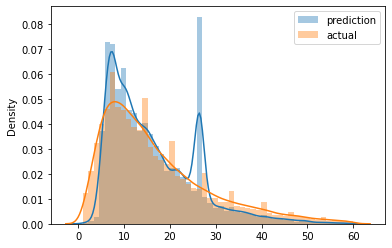

In [19]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train,label='actual')

plt.legend()

In [20]:
import sklearn
print(sklearn.__version__)

1.0.2


In [21]:
with open('models/lin_reg.bin', 'wb' ) as f_out:
    pickle.dump((dv, lr), f_out)
    

In [22]:
with mlflow.start_run():

    mlflow.set_tag("developer","eriton")
    
    mlflow.log_param("train-data-path", "./data/green_tripdata_2021-01.parquet")
    mlflow.log_param("valid-data-path", "./data/green_tripdata_2021-02.parquet")
    
    alpha= 0.01
    
    mlflow.log_param("alpha", alpha)
    

    lr = Lasso(alpha=0.1)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)

    rmse = mean_squared_error(y_val, y_pred, squared=False)
    
    mlflow.log_metric("rmse", rmse)
    

In [23]:
import xgboost as xgb

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope 



In [24]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [25]:
def objective(params):
   
    with mlflow.start_run():
            mlflow.set_tag("model","xgboost")
            mlflow.log_params(params)
            booster = xgb.train(
                params=params,
                dtrain=train,
                num_boost_round=1000,
                evals=[(valid, "validation")],
                early_stopping_rounds=50
            )

            y_pred = booster.predict(valid)
            rmse = mean_squared_error(y_val, y_pred, squared=False)
            mlflow.log_metric("rmse",rmse)

    return {'loss': rmse, 'status': STATUS_OK}
        

In [ ]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 42,
}

best_reesult = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)

  0%|                                                                       | 0/50 [00:00<?, ?trial/s, best loss=?]

/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [01:30:06] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)



[0]	validation-rmse:7.76941                                                                                        
[1]	validation-rmse:6.91642                                                                                        
[2]	validation-rmse:6.73851                                                                                        
[3]	validation-rmse:6.68571                                                                                        
[4]	validation-rmse:6.66676                                                                                        
[5]	validation-rmse:6.65769                                                                                        
[6]	validation-rmse:6.65270                                                                                        
[7]	validation-rmse:6.64943                                                                                        
[8]	validation-rmse:6.64292                                             

[70]	validation-rmse:6.48991                                                                                       
[71]	validation-rmse:6.48899                                                                                       
[72]	validation-rmse:6.48708                                                                                       
[73]	validation-rmse:6.48475                                                                                       
[74]	validation-rmse:6.48373                                                                                       
[75]	validation-rmse:6.48187                                                                                       
[76]	validation-rmse:6.48045                                                                                       
[77]	validation-rmse:6.47912                                                                                       
[78]	validation-rmse:6.47724                                            

[140]	validation-rmse:6.41412                                                                                      
[141]	validation-rmse:6.41385                                                                                      
[142]	validation-rmse:6.41220                                                                                      
[143]	validation-rmse:6.41069                                                                                      
[144]	validation-rmse:6.41034                                                                                      
[145]	validation-rmse:6.40961                                                                                      
[146]	validation-rmse:6.40895                                                                                      
[147]	validation-rmse:6.40866                                                                                      
[148]	validation-rmse:6.40782                                           

...

[350]	validation-rmse:6.38293                                                                                      
[351]	validation-rmse:6.38292                                                                                      
[352]	validation-rmse:6.38290                                                                                      
[353]	validation-rmse:6.38287                                                                                      
[354]	validation-rmse:6.38270                                                                                      
[355]	validation-rmse:6.38273                                                                                      
[356]	validation-rmse:6.38285                                                                                      
[357]	validation-rmse:6.38260                                                                                      
[358]	validation-rmse:6.38212                                           

[420]	validation-rmse:6.38134                                                                                      
[421]	validation-rmse:6.38108                                                                                      
[422]	validation-rmse:6.38104                                                                                      
[423]	validation-rmse:6.38109                                                                                      
[424]	validation-rmse:6.38108                                                                                      
[425]	validation-rmse:6.38103                                                                                      
[426]	validation-rmse:6.38101                                                                                      
[427]	validation-rmse:6.38081                                                                                      
[428]	validation-rmse:6.38075                                           

[490]	validation-rmse:6.38084                                                                                      
[491]	validation-rmse:6.38092                                                                                      
[492]	validation-rmse:6.38095                                                                                      
[493]	validation-rmse:6.38085                                                                                      
[494]	validation-rmse:6.38076                                                                                      
[495]	validation-rmse:6.38085                                                                                      
[496]	validation-rmse:6.38091                                                                                      
[497]	validation-rmse:6.38099                                                                                      
[498]	validation-rmse:6.38096                                           

/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [01:36:51] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)



[0]	validation-rmse:10.66135                                                                                       
  8%|███▍                                       | 4/50 [06:51<1:33:03, 121.38s/trial, best loss: 6.361926003464646]

In [ ]:
lr = Ridge()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

mean_squared_error(y_val, y_pred, squared=False)